# CV analysis: chemthenelectro decell chicken (2026-05-07 17:13)

Pairs the scope force-sensor log with the potentiostat CV log from the same run.
Two cycles, +1 V → −1 V → +1 V at 5 mV/s.

- Scope: `scope_log_20260507_171312-chemthenelectro-decell-chicken-results-that-finallymakesense.csv`
- Potentiostat: `data_from_potentiostat/05.07.26_decellchick_chemthenelectropol-fixed-length-PC-cyclicvoltametry-results-that-finally-make-sense.csv`

Scope started ~91 s before the potentiostat measurement (per metadata timestamps).
Force conversion on the secondary y-axis is **56.7 mN/V**.

In [1]:
# Load both files, time-align, and filter outliers from the scope log.

import os
import io
import csv
import numpy as np
import pandas as pd
from datetime import datetime

SCOPE_CSV = 'scope_log_20260507_171312-chemthenelectro-decell-chicken-results-that-finallymakesense.csv'
POTEN_CSV = 'data_from_potentiostat/05.07.26_decellchick_chemthenelectropol-fixed-length-PC-cyclicvoltametry-results-that-finally-make-sense.csv'

DT = 0.2          # potentiostat sample interval (s)
WINDOW = 41       # MAD outlier-filter rolling window (samples)
K = 5.0           # outlier threshold (multiples of MAD)


# ---- 1. Potentiostat (UTF-16, 6-line header, two scans side-by-side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('\ufeff', '')

lines = text.splitlines()
poten_start_str = lines[4].split(',')[1].strip()
poten_start = datetime.strptime(poten_start_str, '%Y-%m-%d %H:%M:%S')

data_rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
data_rows = [r for r in data_rows if len(r) >= 4 and r[0]]
poten = pd.DataFrame(data_rows, columns=['v1', 'i1_uA', 'v2', 'i2_uA']).astype(float)

n_per_scan = len(poten)
t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan, t_scan + n_per_scan * DT])
v_applied_full = np.concatenate([poten['v1'].values, poten['v2'].values])
exp_total_s = 2 * n_per_scan * DT


# ---- 2. Scope log + time alignment ----
scope = pd.read_csv(SCOPE_CSV)
scope_start = (datetime.fromisoformat(scope['timestamp'].iloc[0])
               - pd.Timedelta(seconds=float(scope['elapsed_s'].iloc[0])))
offset_s = (poten_start - scope_start).total_seconds()
print(f'Scope start:        {scope_start}')
print(f'Potentiostat start: {poten_start}')
print(f'Offset (poten - scope): {offset_s:.2f} s')

scope['t_exp'] = scope['elapsed_s'] - offset_s
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)}')


# ---- 3. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in['ch2_MEAN_V'].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()


# ---- 4. Map scope samples to applied voltage ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = (scope_clean['t_exp'].values >= n_per_scan * DT).astype(int)
scope_clean.head()

Scope start:        2026-05-07 17:13:12.963107
Potentiostat start: 2026-05-07 17:14:44
Offset (poten - scope): 91.04 s
Scope rows in experiment window: 3143 / 3327
Flagged 27 of 3143 in-window scope samples (0.86%) as outliers.


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
184,91.0838,2026-05-07T17:14:44.046928,0.0,4.976837,0.046907,0.999802,0
185,91.5811,2026-05-07T17:14:44.544213,0.0,4.977036,0.544207,0.997336,0
186,92.0748,2026-05-07T17:14:45.037869,0.0,4.976980,1.037907,0.994865,0
187,92.5442,2026-05-07T17:14:45.507279,0.0,4.976935,1.507307,0.992545,0
188,93.0408,2026-05-07T17:14:46.003859,0.0,4.976899,2.003907,0.990101,0


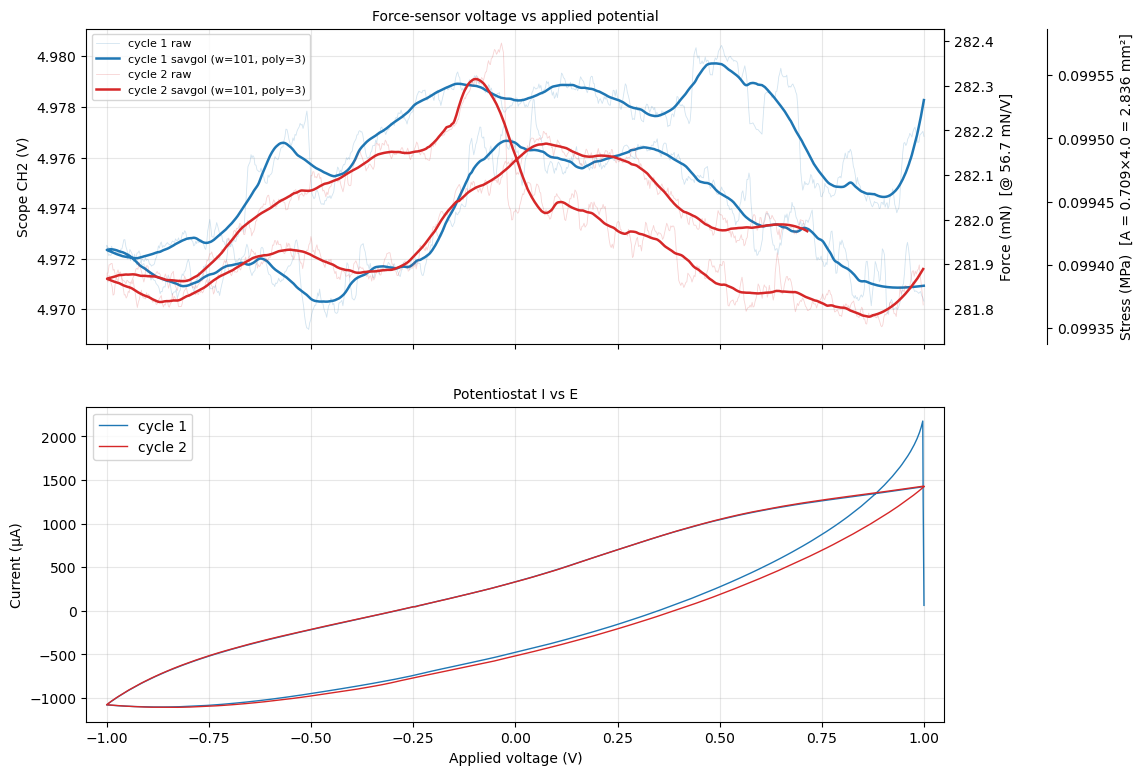

In [2]:
# Two-panel plot, shared x-axis (applied voltage, -1 to +1 V).
# Top:    scope CH2 voltage with smoothed curve fit (raw faint behind).
#         Right side carries TWO axes: force (mN) and stress (MPa).
# Bottom: potentiostat current.
# Cycles colored consistently across panels.

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline

# --- Sample geometry / calibration ---
FORCE_GAIN_MN_PER_V = 56.7
THICKNESS_MM = 0.7090
WIDTH_MM = 4.0
AREA_MM2 = THICKNESS_MM * WIDTH_MM   # 2.836 mm^2
# 1 MPa = 1 N / mm^2.  Force (mN) -> N is /1000, then /AREA_MM2 gives MPa.
STRESS_PER_V_MPA = FORCE_GAIN_MN_PER_V / 1000.0 / AREA_MM2  # MPa per scope-V

CYCLE_COLORS = ['#1f77b4', '#d62728']  # cycle 1 blue, cycle 2 red

# Smoothing options for the force trace:
#   'median'  — rolling median, robust to remaining spikes
#   'mean'    — rolling average, smoother but biased by outliers
#   'savgol'  — Savitzky-Golay, sliding low-order polynomial fit
#   'spline'  — UnivariateSpline, single smooth curve through each cycle
SMOOTH_KIND = 'savgol'
SMOOTH_WINDOW = 101
SAVGOL_POLY = 3
SPLINE_SMOOTHNESS = None
RAW_ALPHA = 0.20


def smooth_per_cycle(df, value_col, kind='savgol', window=51, poly=3, spline_s=None):
    """Smooth value_col within each cycle (no smoothing across cycle boundary)."""
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        x = sub['t_exp'].values
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        if kind == 'median':
            sm = pd.Series(y).rolling(window, center=True, min_periods=1).median().values
        elif kind == 'mean':
            sm = pd.Series(y).rolling(window, center=True, min_periods=1).mean().values
        elif kind == 'savgol':
            w = min(window, n)
            if w % 2 == 0:
                w -= 1
            if w <= poly:
                sm = y
            else:
                sm = savgol_filter(y, window_length=w, polyorder=poly)
        elif kind == 'spline':
            s_param = spline_s if spline_s is not None else n * np.var(y) * 0.05
            spl = UnivariateSpline(x, y, s=s_param)
            sm = spl(x)
        else:
            raise ValueError(f'unknown SMOOTH_KIND={kind!r}')
        out.loc[sub.index] = sm
    return out


scope_clean['ch2_smooth'] = smooth_per_cycle(
    scope_clean, 'ch2_MEAN_V',
    kind=SMOOTH_KIND, window=SMOOTH_WINDOW,
    poly=SAVGOL_POLY, spline_s=SPLINE_SMOOTHNESS,
)


fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Top: scope force trace + smoothed curve ---
ax_v = axes[0]
for cyc in (0, 1):
    sub = scope_clean[scope_clean['cycle'] == cyc].sort_values('t_exp')
    ax_v.plot(sub['v_applied'], sub['ch2_MEAN_V'],
              color=CYCLE_COLORS[cyc], lw=0.6, alpha=RAW_ALPHA,
              label=f'cycle {cyc + 1} raw')
    if SMOOTH_KIND == 'savgol':
        smooth_label = f'cycle {cyc + 1} savgol (w={SMOOTH_WINDOW}, poly={SAVGOL_POLY})'
    elif SMOOTH_KIND == 'spline':
        smooth_label = f'cycle {cyc + 1} spline'
    else:
        smooth_label = f'cycle {cyc + 1} {SMOOTH_KIND} (w={SMOOTH_WINDOW})'
    ax_v.plot(sub['v_applied'], sub['ch2_smooth'],
              color=CYCLE_COLORS[cyc], lw=1.8, label=smooth_label)
ax_v.set_ylabel('Scope CH2 (V)')
ax_v.set_title('Force-sensor voltage vs applied potential', fontsize=10)
ax_v.grid(True, alpha=0.3)
ax_v.legend(loc='best', fontsize=8)

# Secondary axis #1: force in mN (right edge of plot)
ax_f = ax_v.secondary_yaxis(
    'right',
    functions=(lambda v: v * FORCE_GAIN_MN_PER_V, lambda mn: mn / FORCE_GAIN_MN_PER_V),
)
ax_f.set_ylabel(f'Force (mN)  [@ {FORCE_GAIN_MN_PER_V} mN/V]')

# Secondary axis #2: stress in MPa (offset further right so it doesn't overlap)
ax_s = ax_v.secondary_yaxis(
    1.12,
    functions=(lambda v: v * STRESS_PER_V_MPA, lambda mpa: mpa / STRESS_PER_V_MPA),
)
ax_s.set_ylabel(
    f'Stress (MPa)  [A = {THICKNESS_MM}×{WIDTH_MM} = {AREA_MM2:.3f} mm²]'
)

# --- Bottom: potentiostat current ---
ax_i = axes[1]
ax_i.plot(poten['v1'], poten['i1_uA'], color=CYCLE_COLORS[0], lw=1.0, label='cycle 1')
ax_i.plot(poten['v2'], poten['i2_uA'], color=CYCLE_COLORS[1], lw=1.0, label='cycle 2')
ax_i.set_xlabel('Applied voltage (V)')
ax_i.set_ylabel('Current (µA)')
ax_i.set_title('Potentiostat I vs E', fontsize=10)
ax_i.grid(True, alpha=0.3)
ax_i.legend(loc='best')

for a in axes:
    a.set_xlim(-1.05, 1.05)

# Make room on the right for the offset stress axis
fig.subplots_adjust(right=0.84)
plt.show()
